# Backpropagation Derivation for 2–Hidden–1 Neural Network

---

## 1. Forward Pass



### Hidden Layer

$$
z^{(1)} = W^{(1)}x + b^{(1)}
$$

$$
a^{(1)} = \tanh(z^{(1)})
$$

---

### Output Layer

$$
z^{(2)} = W^{(2)}a^{(1)} + b^{(2)}
$$

---

## 2. Output Activation

### XOR (Classification)

$$
\hat{y} = \sigma(z^{(2)})
$$

where

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

---

### Cosine (Regression)

$$
\hat{y} = z^{(2)}
$$

Since,

$$
z^{(2)} = W^{(2)} a^{(1)} + b^{(2)}
$$

Therefore,

$$
\hat{y} = W^{(2)} a^{(1)} + b^{(2)}
$$

---

## 3. Loss Functions

### XOR – Binary Cross Entropy

$$
L = -\left[y \log(\hat{y}) + (1-y)\log(1-\hat{y})\right]
$$

---

### Cosine – Mean Squared Error

$$
L = \frac{1}{2}(y - \hat{y})^2
$$

---

## 4. Output Layer Gradient

### Case 1: XOR (Sigmoid + BCE)



$$
\frac{\partial L}{\partial z^{(2)}} = \hat{y} - y
$$

Define:

$$
\delta^{(2)} = \hat{y} - y
$$

---

### Case 2: Cosine (Linear + MSE)

Since

$$
\hat{y} = z^{(2)}
$$

Derivative:

$$
\frac{\partial L}{\partial z^{(2)}} = \hat{y} - y
$$

Thus,

$$
\delta^{(2)} = \hat{y} - y
$$

---

## 5. Gradients of Output Weights

$$
\frac{\partial L}{\partial W^{(2)}} = a^{(1)} \delta^{(2)}
$$

$$
\frac{\partial L}{\partial b^{(2)}} = \delta^{(2)}
$$

---

## 6. Hidden Layer Gradient


$$
\delta^{(1)} = \left(W^{(2)}\right)^T \delta^{(2)} \circ \tanh'(z^{(1)})
$$

where

$$
\tanh'(z) = 1 - \tanh^2(z)
$$

---

## 7. Gradients of Hidden Weights

$$
\frac{\partial L}{\partial W^{(1)}} = x \delta^{(1)}
$$

$$
\frac{\partial L}{\partial b^{(1)}} = \delta^{(1)}
$$

---

## 8. Weight Update Rule

Using Gradient Descent:

$$
W \leftarrow W - \eta \frac{\partial L}{\partial W}
$$

$$
b \leftarrow b - \eta \frac{\partial L}{\partial b}
$$

where \( \eta \) is the learning rate.



Epoch 0: Train Loss=0.2509, Test Loss=0.2496, Train Acc=38.00%, Test Acc=38.00%
Epoch 200: Train Loss=0.2500, Test Loss=0.2494, Train Acc=49.00%, Test Acc=54.00%
Epoch 400: Train Loss=0.2495, Test Loss=0.2489, Train Acc=43.62%, Test Acc=48.50%
Epoch 600: Train Loss=0.2485, Test Loss=0.2475, Train Acc=45.00%, Test Acc=44.00%
Epoch 800: Train Loss=0.2443, Test Loss=0.2425, Train Acc=49.38%, Test Acc=51.00%
Epoch 1000: Train Loss=0.2254, Test Loss=0.2221, Train Acc=49.62%, Test Acc=51.50%
Epoch 1200: Train Loss=0.1872, Test Loss=0.1824, Train Acc=49.62%, Test Acc=51.50%
Epoch 1400: Train Loss=0.1613, Test Loss=0.1560, Train Acc=51.75%, Test Acc=54.00%
Epoch 1600: Train Loss=0.1491, Test Loss=0.1438, Train Acc=56.38%, Test Acc=59.00%
Epoch 1800: Train Loss=0.1429, Test Loss=0.1375, Train Acc=61.25%, Test Acc=63.00%
Epoch 2000: Train Loss=0.1392, Test Loss=0.1339, Train Acc=65.12%, Test Acc=67.00%
Epoch 2200: Train Loss=0.1368, Test Loss=0.1316, Train Acc=67.62%, Test Acc=67.50%
Epoch 2400:

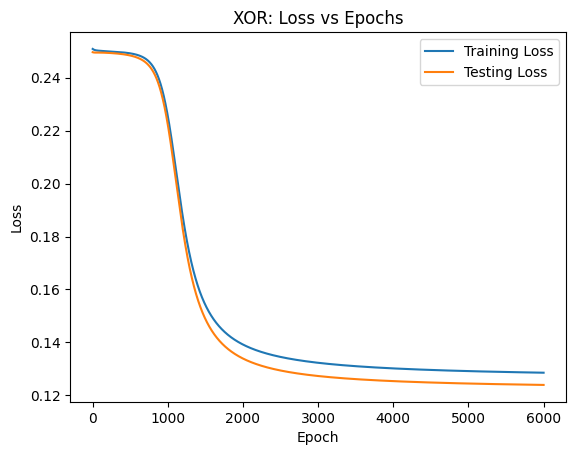

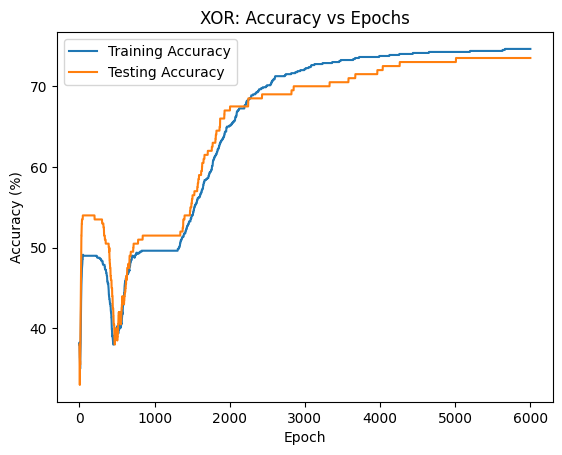

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Data Generation (XOR)
# =========================

def generate_xor_dataset(samples_per_point=250, noise_std=0.1, seed=42):
    np.random.seed(seed)

    base_points = np.array([
        [0.0, 0.0],
        [0.0, 1.0],
        [1.0, 0.0],
        [1.0, 1.0]
    ])

    base_labels = np.array([0, 1, 1, 0])

    X_list = []
    y_list = []

    for i in range(4):
        point = base_points[i]
        label = base_labels[i]
        noisy_samples = point + np.random.normal(0.0, noise_std, size=(samples_per_point, 2))
        X_list.append(noisy_samples)
        y_list.append(np.full(samples_per_point, label))

    X = np.vstack(X_list)
    y = np.hstack(y_list)

    indices = np.random.permutation(len(X))
    X = X[indices]
    y = y[indices]

    split = int(0.8 * len(X))
    X_train = X[:split]
    y_train = y[:split].reshape(-1, 1)
    X_test = X[split:]
    y_test = y[split:].reshape(-1, 1)

    return X_train, y_train, X_test, y_test


# =========================
# Activations and Loss
# =========================

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1.0 - s)

def tanh(x):
    return np.tanh(x)

def tanh_derivative(x):
    return 1.0 - np.tanh(x)**2

def mse_loss(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)


# =========================
# Accuracy
# =========================

def accuracy_xor(y_true, y_pred):
    y_pred_class = (y_pred >= 0.5).astype(int)
    correct = np.sum(y_pred_class == y_true)
    return (correct / len(y_true)) * 100.0


# =========================
# Neural Network
# =========================

class SimpleANN:
    def __init__(self, input_size, hidden_size, output_size, seed=42):
        np.random.seed(seed)

        # Better initialization (NOT too small)
        self.W1 = np.random.randn(input_size, hidden_size) * 0.5
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size) * 0.5
        self.b2 = np.zeros((1, output_size))

    def forward(self, X):
        self.z_hidden = np.dot(X, self.W1) + self.b1
        self.a_hidden = tanh(self.z_hidden)
        self.z_out = np.dot(self.a_hidden, self.W2) + self.b2
        self.y_pred = sigmoid(self.z_out)
        return self.y_pred

    def backward(self, X, y_true):
        batch_size = X.shape[0]

        # dL/dy
        dL_dy = 2.0 * (self.y_pred - y_true) / batch_size

        # dL/dz_out
        dL_dz_out = dL_dy * sigmoid_derivative(self.z_out)

        # Gradients for W2, b2
        self.dW2 = np.dot(self.a_hidden.T, dL_dz_out)
        self.db2 = np.sum(dL_dz_out, axis=0, keepdims=True)

        # Backprop to hidden
        dL_da_hidden = np.dot(dL_dz_out, self.W2.T)
        dL_dz_hidden = dL_da_hidden * tanh_derivative(self.z_hidden)

        # Gradients for W1, b1
        self.dW1 = np.dot(X.T, dL_dz_hidden)
        self.db1 = np.sum(dL_dz_hidden, axis=0, keepdims=True)

    def update_weights(self, lr):
        self.W1 -= lr * self.dW1
        self.b1 -= lr * self.db1
        self.W2 -= lr * self.dW2
        self.b2 -= lr * self.db2


# =========================
# Training Loop
# =========================

def train(net, X_train, y_train, X_test, y_test, epochs=6000, learning_rate=0.15, batch_size=None):
    n_train = X_train.shape[0]

    train_losses, test_losses = [], []
    train_accs, test_accs = [], []

    for epoch in range(epochs):
        indices = np.random.permutation(n_train)
        X_train_shuffled = X_train[indices]
        y_train_shuffled = y_train[indices]

        if batch_size is None:
            batch_size = n_train

        for start in range(0, n_train, batch_size):
            end = start + batch_size
            X_batch = X_train_shuffled[start:end]
            y_batch = y_train_shuffled[start:end]

            net.forward(X_batch)
            net.backward(X_batch, y_batch)
            net.update_weights(learning_rate)

        # Train metrics
        y_train_pred = net.forward(X_train)
        train_loss = mse_loss(y_train, y_train_pred)
        train_acc = accuracy_xor(y_train, y_train_pred)

        # Test metrics
        y_test_pred = net.forward(X_test)
        test_loss = mse_loss(y_test, y_test_pred)
        test_acc = accuracy_xor(y_test, y_test_pred)

        train_losses.append(train_loss)
        test_losses.append(test_loss)
        train_accs.append(train_acc)
        test_accs.append(test_acc)

        if epoch % 200 == 0:
            print(f"Epoch {epoch}: Train Loss={train_loss:.4f}, Test Loss={test_loss:.4f}, "
                  f"Train Acc={train_acc:.2f}%, Test Acc={test_acc:.2f}%")

    return train_losses, test_losses, train_accs, test_accs


# =========================
# Run XOR Experiment
# =========================

X_train, y_train, X_test, y_test = generate_xor_dataset(samples_per_point=250, noise_std=0.1)

net = SimpleANN(input_size=2, hidden_size=2, output_size=1)

train_losses, test_losses, train_accs, test_accs = train(
    net, X_train, y_train, X_test, y_test,
    epochs=6000, learning_rate=0.15, batch_size=None
)

print("\nTraining finished (XOR)")
print("Final Training Loss:", train_losses[-1])
print("Final Testing Loss:", test_losses[-1])
print("Final Training Accuracy:", train_accs[-1], "%")
print("Final Testing Accuracy:", test_accs[-1], "%")

# Plot Loss
epochs_arr = np.arange(1, len(train_losses) + 1)
plt.figure()
plt.plot(epochs_arr, train_losses, label="Training Loss")
plt.plot(epochs_arr, test_losses, label="Testing Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("XOR: Loss vs Epochs")
plt.legend()
plt.show()

# Plot Accuracy
plt.figure()
plt.plot(epochs_arr, train_accs, label="Training Accuracy")
plt.plot(epochs_arr, test_accs, label="Testing Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("XOR: Accuracy vs Epochs")
plt.legend()
plt.show()

Epoch 0: Train Loss=0.8512, Test Loss=0.8398, Train Acc=13.75%, Test Acc=14.75%
Epoch 500: Train Loss=0.1603, Test Loss=0.1537, Train Acc=13.69%, Test Acc=13.50%
Epoch 1000: Train Loss=0.0983, Test Loss=0.0951, Train Acc=17.06%, Test Acc=18.00%
Epoch 1500: Train Loss=0.0567, Test Loss=0.0553, Train Acc=21.94%, Test Acc=22.25%
Epoch 2000: Train Loss=0.0311, Test Loss=0.0305, Train Acc=33.06%, Test Acc=32.25%
Epoch 2500: Train Loss=0.0170, Test Loss=0.0168, Train Acc=48.19%, Test Acc=47.75%

Training finished (Cosine)
Final Training Loss: 0.009903358336597019
Final Testing Loss: 0.009933663772521415
Final Training Accuracy: 64.875 %
Final Testing Accuracy: 64.25 %


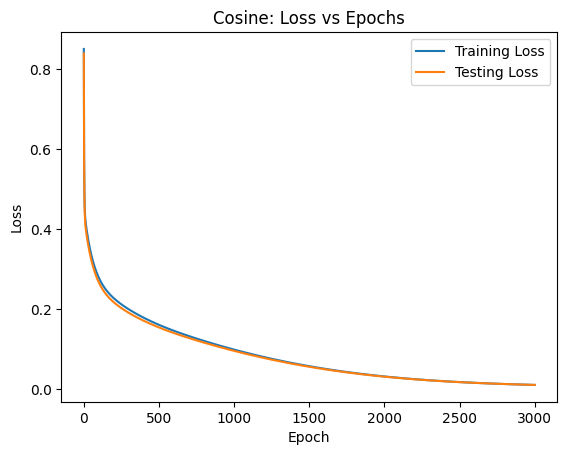

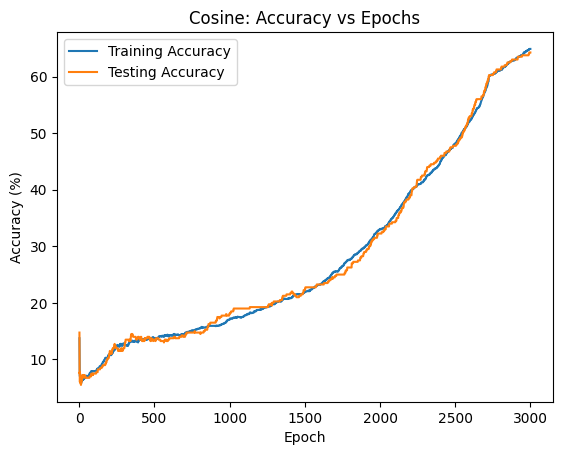

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Data Generation (Cosine)
# =========================

def generate_cosine_dataset(n_samples=1000, x_min=0.0, x_max=2*np.pi, noise_std=0.1, seed=42):
    np.random.seed(seed)

    X = np.random.uniform(x_min, x_max, size=(n_samples, 1))
    X_noisy = X + np.random.normal(0.0, noise_std, size=X.shape)
    y = np.cos(X_noisy)

    indices = np.random.permutation(n_samples)
    X_noisy = X_noisy[indices]
    y = y[indices]

    split = int(0.8 * n_samples)
    X_train = X_noisy[:split]
    y_train = y[:split]
    X_test = X_noisy[split:]
    y_test = y[split:]

    return X_train, y_train, X_test, y_test


# =========================
# Activations and Loss
# =========================

def tanh(x):
    return np.tanh(x)

def tanh_derivative(x):
    return 1.0 - np.tanh(x)**2

def linear(x):
    return x

def linear_derivative(x):
    return np.ones_like(x)

def mse_loss(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)


# =========================
# Accuracy (Cosine)
# =========================

def accuracy_cosine(y_true, y_pred, eps=0.1):
    correct = np.sum(np.abs(y_pred - y_true) < eps)
    return (correct / len(y_true)) * 100.0


# =========================
# Neural Network
# =========================

class SimpleANN:
    def __init__(self, input_size, hidden_size, output_size, seed=42):
        np.random.seed(seed)

        self.W1 = np.random.randn(input_size, hidden_size) * 0.5
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size) * 0.5
        self.b2 = np.zeros((1, output_size))

    def forward(self, X):
        self.z_hidden = np.dot(X, self.W1) + self.b1
        self.a_hidden = tanh(self.z_hidden)
        self.z_out = np.dot(self.a_hidden, self.W2) + self.b2
        self.y_pred = linear(self.z_out)
        return self.y_pred

    def backward(self, X, y_true):
        batch_size = X.shape[0]

        dL_dy = 2.0 * (self.y_pred - y_true) / batch_size
        dL_dz_out = dL_dy * linear_derivative(self.z_out)

        self.dW2 = np.dot(self.a_hidden.T, dL_dz_out)
        self.db2 = np.sum(dL_dz_out, axis=0, keepdims=True)

        dL_da_hidden = np.dot(dL_dz_out, self.W2.T)
        dL_dz_hidden = dL_da_hidden * tanh_derivative(self.z_hidden)

        self.dW1 = np.dot(X.T, dL_dz_hidden)
        self.db1 = np.sum(dL_dz_hidden, axis=0, keepdims=True)

    def update_weights(self, lr):
        self.W1 -= lr * self.dW1
        self.b1 -= lr * self.db1
        self.W2 -= lr * self.dW2
        self.b2 -= lr * self.db2


# =========================
# Training Loop
# =========================

def train(net, X_train, y_train, X_test, y_test,
          epochs=3000, learning_rate=0.01, batch_size=None):

    n_train = X_train.shape[0]

    train_losses, test_losses = [], []
    train_accs, test_accs = [], []

    for epoch in range(epochs):

        indices = np.random.permutation(n_train)
        X_train_shuffled = X_train[indices]
        y_train_shuffled = y_train[indices]

        if batch_size is None:
            batch_size = n_train

        for start in range(0, n_train, batch_size):
            end = start + batch_size
            X_batch = X_train_shuffled[start:end]
            y_batch = y_train_shuffled[start:end]

            net.forward(X_batch)
            net.backward(X_batch, y_batch)
            net.update_weights(learning_rate)

        # Metrics
        y_train_pred = net.forward(X_train)
        train_loss = mse_loss(y_train, y_train_pred)
        train_acc = accuracy_cosine(y_train, y_train_pred)

        y_test_pred = net.forward(X_test)
        test_loss = mse_loss(y_test, y_test_pred)
        test_acc = accuracy_cosine(y_test, y_test_pred)

        train_losses.append(train_loss)
        test_losses.append(test_loss)
        train_accs.append(train_acc)
        test_accs.append(test_acc)

        if epoch % 500 == 0:
            print(f"Epoch {epoch}: Train Loss={train_loss:.4f}, "
                  f"Test Loss={test_loss:.4f}, "
                  f"Train Acc={train_acc:.2f}%, "
                  f"Test Acc={test_acc:.2f}%")

    return train_losses, test_losses, train_accs, test_accs


# =========================
# Run Cosine Experiment
# =========================

X_train, y_train, X_test, y_test = generate_cosine_dataset(n_samples=2000)

net = SimpleANN(input_size=1, hidden_size=10, output_size=1)

train_losses, test_losses, train_accs, test_accs = train(
    net, X_train, y_train, X_test, y_test,
    epochs=3000, learning_rate=0.01
)

print("\nTraining finished (Cosine)")
print("Final Training Loss:", train_losses[-1])
print("Final Testing Loss:", test_losses[-1])
print("Final Training Accuracy:", train_accs[-1], "%")
print("Final Testing Accuracy:", test_accs[-1], "%")

# Plot Loss
epochs_arr = np.arange(1, len(train_losses) + 1)
plt.figure()
plt.plot(epochs_arr, train_losses, label="Training Loss")
plt.plot(epochs_arr, test_losses, label="Testing Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Cosine: Loss vs Epochs")
plt.legend()
plt.show()

# Plot Accuracy
plt.figure()
plt.plot(epochs_arr, train_accs, label="Training Accuracy")
plt.plot(epochs_arr, test_accs, label="Testing Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Cosine: Accuracy vs Epochs")
plt.legend()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# ACTIVATION FUNCTIONS
# ============================================================

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1.0 - s)

def tanh(x):
    return np.tanh(x)

def tanh_derivative(x):
    return 1.0 - np.tanh(x)**2

def linear(x):
    return x

def linear_derivative(x):
    return np.ones_like(x)

# ============================================================
# LOSS FUNCTION
# ============================================================

def mse_loss(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

# ============================================================
# ACCURACY FUNCTIONS
# ============================================================

def accuracy_xor(y_true, y_pred):
    y_pred_class = (y_pred >= 0.5).astype(int)
    return (np.sum(y_pred_class == y_true) / len(y_true)) * 100.0

def accuracy_cosine(y_true, y_pred, eps=0.1):
    return (np.sum(np.abs(y_pred - y_true) < eps) / len(y_true)) * 100.0

# ============================================================
# DATA GENERATION
# ============================================================

def generate_xor_dataset(samples_per_point=250, noise_std=0.1, seed=42):
    np.random.seed(seed)

    base_points = np.array([[0,0],[0,1],[1,0],[1,1]])
    base_labels = np.array([0,1,1,0])

    X_list, y_list = [], []

    for i in range(4):
        noisy = base_points[i] + np.random.normal(0, noise_std, (samples_per_point,2))
        X_list.append(noisy)
        y_list.append(np.full(samples_per_point, base_labels[i]))

    X = np.vstack(X_list)
    y = np.hstack(y_list).reshape(-1,1)

    idx = np.random.permutation(len(X))
    X, y = X[idx], y[idx]

    split = int(0.8 * len(X))
    return X[:split], y[:split], X[split:], y[split:]


def generate_cosine_dataset(n_samples=2000, noise_std=0.1, seed=42):
    np.random.seed(seed)

    X = np.random.uniform(0, 2*np.pi, (n_samples,1))
    X += np.random.normal(0, noise_std, X.shape)
    y = np.cos(X)

    idx = np.random.permutation(len(X))
    X, y = X[idx], y[idx]

    split = int(0.8 * n_samples)
    return X[:split], y[:split], X[split:], y[split:]

# ============================================================
# UNIFIED ANN CLASS
# ============================================================

class SimpleANN:

    def __init__(self, input_size, hidden_size, output_size,
                 hidden_act, hidden_act_deriv,
                 output_act, output_act_deriv,
                 seed=42):

        np.random.seed(seed)

        self.hidden_act = hidden_act
        self.hidden_act_deriv = hidden_act_deriv
        self.output_act = output_act
        self.output_act_deriv = output_act_deriv

        self.W1 = np.random.randn(input_size, hidden_size) * 0.5
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size) * 0.5
        self.b2 = np.zeros((1, output_size))

    def forward(self, X):
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = self.hidden_act(self.z1)
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.y_pred = self.output_act(self.z2)
        return self.y_pred

    def backward(self, X, y_true):
        m = X.shape[0]

        dL_dy = 2.0 * (self.y_pred - y_true) / m
        dL_dz2 = dL_dy * self.output_act_deriv(self.z2)

        self.dW2 = np.dot(self.a1.T, dL_dz2)
        self.db2 = np.sum(dL_dz2, axis=0, keepdims=True)

        dL_da1 = np.dot(dL_dz2, self.W2.T)
        dL_dz1 = dL_da1 * self.hidden_act_deriv(self.z1)

        self.dW1 = np.dot(X.T, dL_dz1)
        self.db1 = np.sum(dL_dz1, axis=0, keepdims=True)

    def update(self, lr):
        self.W1 -= lr * self.dW1
        self.b1 -= lr * self.db1
        self.W2 -= lr * self.dW2
        self.b2 -= lr * self.db2

# ============================================================
# TRAIN FUNCTION (Unified)
# ============================================================

def train(net, X_train, y_train, X_test, y_test,
          epochs, learning_rate, batch_size, task):

    n = X_train.shape[0]

    train_losses, test_losses = [], []
    train_accs, test_accs = [], []

    for epoch in range(epochs):

        idx = np.random.permutation(n)
        X_train_shuffled = X_train[idx]
        y_train_shuffled = y_train[idx]

        if batch_size is None:
            batch_size = n

        for start in range(0, n, batch_size):
            end = start + batch_size
            X_batch = X_train_shuffled[start:end]
            y_batch = y_train_shuffled[start:end]

            net.forward(X_batch)
            net.backward(X_batch, y_batch)
            net.update(learning_rate)

        y_train_pred = net.forward(X_train)
        y_test_pred = net.forward(X_test)

        train_losses.append(mse_loss(y_train, y_train_pred))
        test_losses.append(mse_loss(y_test, y_test_pred))

        if task == "xor":
            train_accs.append(accuracy_xor(y_train, y_train_pred))
            test_accs.append(accuracy_xor(y_test, y_test_pred))
        else:
            train_accs.append(accuracy_cosine(y_train, y_train_pred))
            test_accs.append(accuracy_cosine(y_test, y_test_pred))

        if epoch % 500 == 0:
            print(f"Epoch {epoch}: Train Loss={train_losses[-1]:.4f}, "
                  f"Test Loss={test_losses[-1]:.4f}")

    return train_losses, test_losses, train_accs, test_accs


# ============================================================
# RUN XOR
# ============================================================

print("\n===== XOR Training =====")

X_train, y_train, X_test, y_test = generate_xor_dataset()

net = SimpleANN(
    input_size=2,
    hidden_size=2,
    output_size=1,
    hidden_act=tanh,
    hidden_act_deriv=tanh_derivative,
    output_act=sigmoid,
    output_act_deriv=sigmoid_derivative
)

train_losses, test_losses, train_accs, test_accs = train(
    net, X_train, y_train, X_test, y_test,
    epochs=2000,
    learning_rate=0.15,
    batch_size=None,
    task="xor"
)

print("Final XOR Train Accuracy:", train_accs[-1])
print("Final XOR Test Accuracy:", test_accs[-1])


# ============================================================
# RUN COSINE
# ============================================================

print("\n===== Cosine Training =====")

X_train, y_train, X_test, y_test = generate_cosine_dataset()

net = SimpleANN(
    input_size=1,
    hidden_size=2,
    output_size=1,
    hidden_act=tanh,
    hidden_act_deriv=tanh_derivative,
    output_act=linear,
    output_act_deriv=linear_derivative
)

train_losses, test_losses, train_accs, test_accs = train(
    net, X_train, y_train, X_test, y_test,
    epochs=3000,
    learning_rate=0.01,
    batch_size=None,
    task="cosine"
)

print("Final Cosine Train Accuracy:", train_accs[-1])
print("Final Cosine Test Accuracy:", test_accs[-1])


===== XOR Training =====
Epoch 0: Train Loss=0.2509, Test Loss=0.2496
Epoch 500: Train Loss=0.2492, Test Loss=0.2484
Epoch 1000: Train Loss=0.2254, Test Loss=0.2221
Epoch 1500: Train Loss=0.1541, Test Loss=0.1488
Final XOR Train Accuracy: 65.125
Final XOR Test Accuracy: 67.0

===== Cosine Training =====
Epoch 0: Train Loss=0.5315, Test Loss=0.5142
Epoch 500: Train Loss=0.4269, Test Loss=0.4112
Epoch 1000: Train Loss=0.3097, Test Loss=0.2960
Epoch 1500: Train Loss=0.2247, Test Loss=0.2144
Epoch 2000: Train Loss=0.1292, Test Loss=0.1234
Epoch 2500: Train Loss=0.0588, Test Loss=0.0562
Final Cosine Train Accuracy: 53.75
Final Cosine Test Accuracy: 54.0



Running Batch GD with dataset size n = 200
Epoch 0: Train Loss=0.2501, Test Loss=0.2527
Epoch 500: Train Loss=0.2484, Test Loss=0.2516
Epoch 1000: Train Loss=0.2362, Test Loss=0.2448
Epoch 1500: Train Loss=0.1868, Test Loss=0.2005
Final Training Loss: 0.15256025109828725
Final Testing Loss: 0.1631616249065929
Final Training Accuracy: 75.0 %
Final Testing Accuracy: 70.0 %


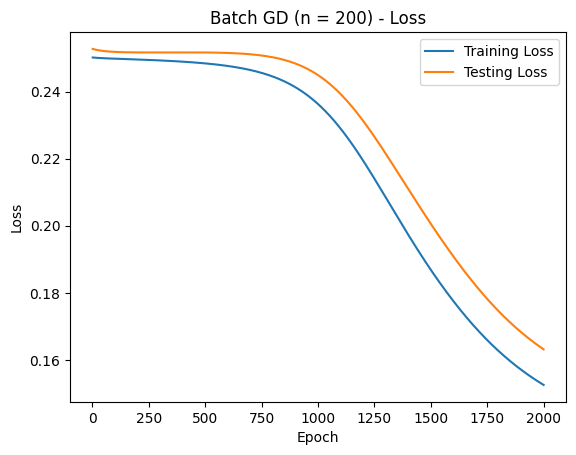

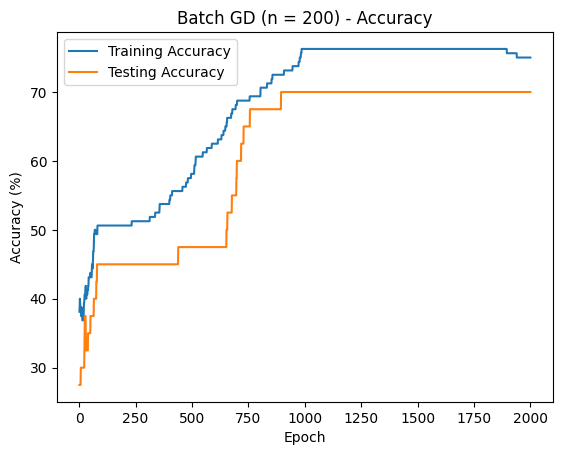


Running Batch GD with dataset size n = 1000
Epoch 0: Train Loss=0.2509, Test Loss=0.2496
Epoch 500: Train Loss=0.2497, Test Loss=0.2491
Epoch 1000: Train Loss=0.2478, Test Loss=0.2465
Epoch 1500: Train Loss=0.2254, Test Loss=0.2221
Final Training Loss: 0.16789642889550963
Final Testing Loss: 0.16276560241837731
Final Training Accuracy: 50.125 %
Final Testing Accuracy: 51.5 %


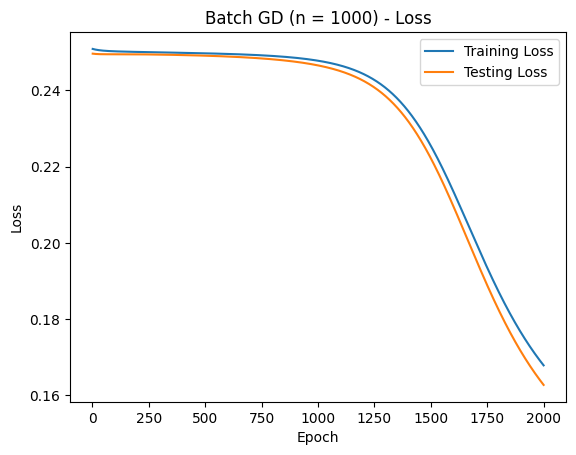

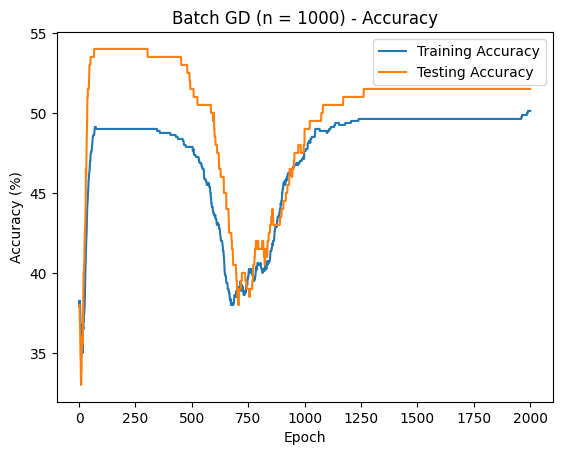


Running Batch GD with dataset size n = 5000
Epoch 0: Train Loss=0.2504, Test Loss=0.2505
Epoch 500: Train Loss=0.2493, Test Loss=0.2492
Epoch 1000: Train Loss=0.2454, Test Loss=0.2451
Epoch 1500: Train Loss=0.2144, Test Loss=0.2136
Final Training Loss: 0.16664745473949502
Final Testing Loss: 0.1651614634520555
Final Training Accuracy: 72.575 %
Final Testing Accuracy: 73.0 %


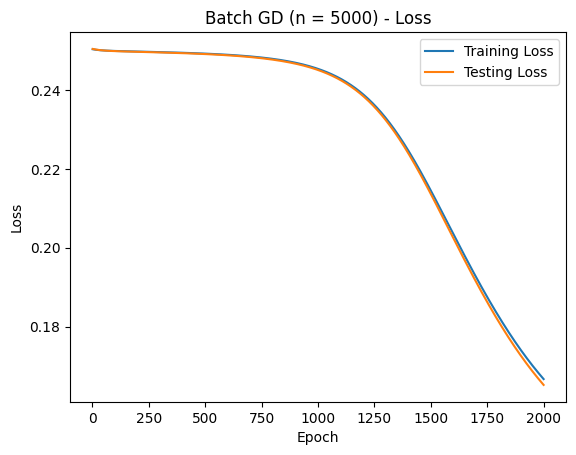

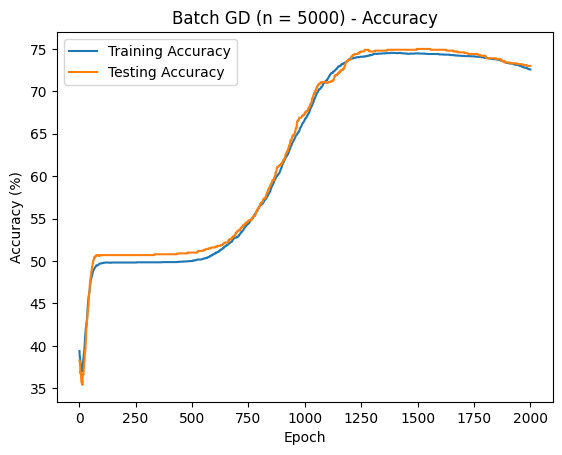

In [ ]:
# =========================
# Deterministic GD Experiment (XOR)
# =========================

n_list = [200, 1000, 5000]

for n in n_list:

    print("\n====================================")
    print(f"Running Batch GD with dataset size n = {n}")
    print("====================================")

    # Generate dataset
    X_train, y_train, X_test, y_test = generate_xor_dataset(
        samples_per_point=n // 4,
        noise_std=0.1
    )

    #  Reinitialize network correctly (NEW CLASS FORMAT)
    net = SimpleANN(
        input_size=2,
        hidden_size=2,
        output_size=1,
        hidden_act=tanh,
        hidden_act_deriv=tanh_derivative,
        output_act=sigmoid,
        output_act_deriv=sigmoid_derivative
    )

    #  Train using FULL Batch GD
    train_losses, test_losses, train_accs, test_accs = train(
        net,
        X_train, y_train,
        X_test, y_test,
        epochs=2000,
        learning_rate=0.1,
        batch_size=None,   # Full batch
        task="xor"         # IMPORTANT
    )

    print("Final Training Loss:", train_losses[-1])
    print("Final Testing Loss:", test_losses[-1])
    print("Final Training Accuracy:", train_accs[-1], "%")
    print("Final Testing Accuracy:", test_accs[-1], "%")

    # Plot Loss
    epochs_arr = np.arange(1, len(train_losses) + 1)

    plt.figure()
    plt.plot(epochs_arr, train_losses, label="Training Loss")
    plt.plot(epochs_arr, test_losses, label="Testing Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Batch GD (n = {n}) - Loss")
    plt.legend()
    plt.show()

    # Plot Accuracy
    plt.figure()
    plt.plot(epochs_arr, train_accs, label="Training Accuracy")
    plt.plot(epochs_arr, test_accs, label="Testing Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.title(f"Batch GD (n = {n}) - Accuracy")
    plt.legend()
    plt.show()


Running Batch GD (Cosine) with dataset size n = 500
Epoch 0: Train Loss=0.5419, Test Loss=0.5435
Epoch 500: Train Loss=0.3861, Test Loss=0.4072
Epoch 1000: Train Loss=0.2857, Test Loss=0.3162
Epoch 1500: Train Loss=0.1981, Test Loss=0.2254
Epoch 2000: Train Loss=0.1080, Test Loss=0.1284
Epoch 2500: Train Loss=0.0485, Test Loss=0.0606
Final Training Loss: 0.020220870028277122
Final Testing Loss: 0.02590892088463626
Final Training Accuracy: 56.49999999999999 %
Final Testing Accuracy: 49.0 %


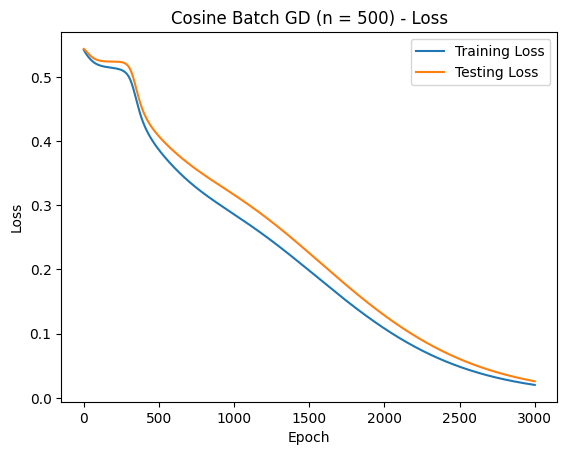

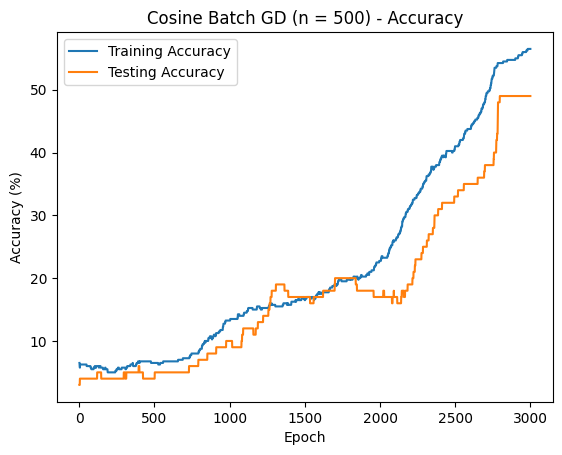


Running Batch GD (Cosine) with dataset size n = 2000
Epoch 0: Train Loss=0.5315, Test Loss=0.5142
Epoch 500: Train Loss=0.4269, Test Loss=0.4112
Epoch 1000: Train Loss=0.3097, Test Loss=0.2960
Epoch 1500: Train Loss=0.2247, Test Loss=0.2144
Epoch 2000: Train Loss=0.1292, Test Loss=0.1234
Epoch 2500: Train Loss=0.0588, Test Loss=0.0562
Final Training Loss: 0.02387372462087292
Final Testing Loss: 0.022800196524993547
Final Training Accuracy: 53.75 %
Final Testing Accuracy: 54.0 %


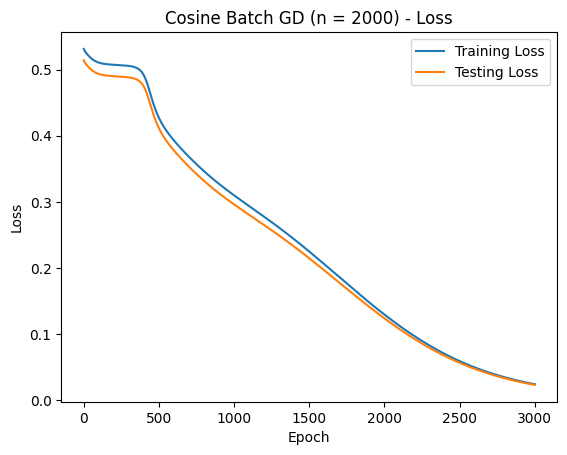

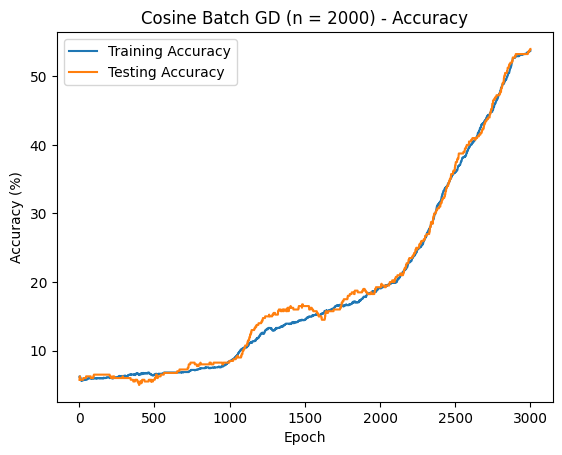


Running Batch GD (Cosine) with dataset size n = 5000
Epoch 0: Train Loss=0.5227, Test Loss=0.5140
Epoch 500: Train Loss=0.3954, Test Loss=0.3912
Epoch 1000: Train Loss=0.2933, Test Loss=0.2903
Epoch 1500: Train Loss=0.2099, Test Loss=0.2068
Epoch 2000: Train Loss=0.1195, Test Loss=0.1176
Epoch 2500: Train Loss=0.0550, Test Loss=0.0543
Final Training Loss: 0.02309294273704837
Final Testing Loss: 0.022901504822719482
Final Training Accuracy: 54.775 %
Final Testing Accuracy: 56.00000000000001 %


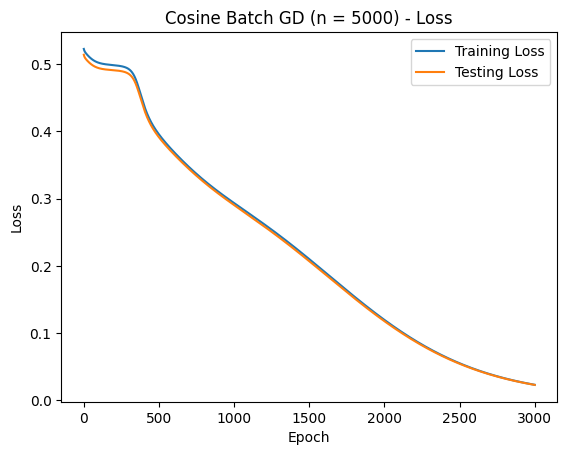

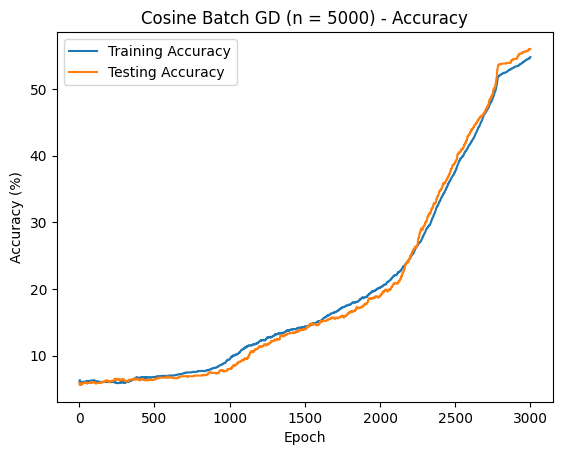

In [ ]:
# ============================================================
# Deterministic GD Experiment (Cosine)
# ============================================================

n_list = [500, 2000, 5000]

for n in n_list:

    print("\n====================================")
    print(f"Running Batch GD (Cosine) with dataset size n = {n}")
    print("====================================")

    # Generate dataset
    X_train, y_train, X_test, y_test = generate_cosine_dataset(
        n_samples=n,
        noise_std=0.1
    )

    # Reinitialize network (Hidden size = 2 as required)
    net = SimpleANN(
        input_size=1,
        hidden_size=2,
        output_size=1,
        hidden_act=tanh,
        hidden_act_deriv=tanh_derivative,
        output_act=linear,
        output_act_deriv=linear_derivative
    )

    # Train with FULL batch GD
    train_losses, test_losses, train_accs, test_accs = train(
        net,
        X_train, y_train,
        X_test, y_test,
        epochs=3000,
        learning_rate=0.01,
        batch_size=None,   # FULL BATCH
        task="cosine"
    )

    print("Final Training Loss:", train_losses[-1])
    print("Final Testing Loss:", test_losses[-1])
    print("Final Training Accuracy:", train_accs[-1], "%")
    print("Final Testing Accuracy:", test_accs[-1], "%")

    # Plot Loss
    epochs_arr = np.arange(1, len(train_losses) + 1)

    plt.figure()
    plt.plot(epochs_arr, train_losses, label="Training Loss")
    plt.plot(epochs_arr, test_losses, label="Testing Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Cosine Batch GD (n = {n}) - Loss")
    plt.legend()
    plt.show()

    # Plot Accuracy
    plt.figure()
    plt.plot(epochs_arr, train_accs, label="Training Accuracy")
    plt.plot(epochs_arr, test_accs, label="Testing Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.title(f"Cosine Batch GD (n = {n}) - Accuracy")
    plt.legend()
    plt.show()


Running Mini-Batch GD with dataset size n = 2000

------------------------------------
Training with batch size m = 1
------------------------------------
Epoch 0: Train Loss=0.2187, Test Loss=0.2290
Epoch 500: Train Loss=0.0000, Test Loss=0.0000
Epoch 1000: Train Loss=0.0000, Test Loss=0.0000
Epoch 1500: Train Loss=0.0000, Test Loss=0.0000
Final Training Loss: 6.325569248067419e-06
Final Testing Loss: 8.224083661671074e-06
Final Training Accuracy: 100.0 %
Final Testing Accuracy: 100.0 %


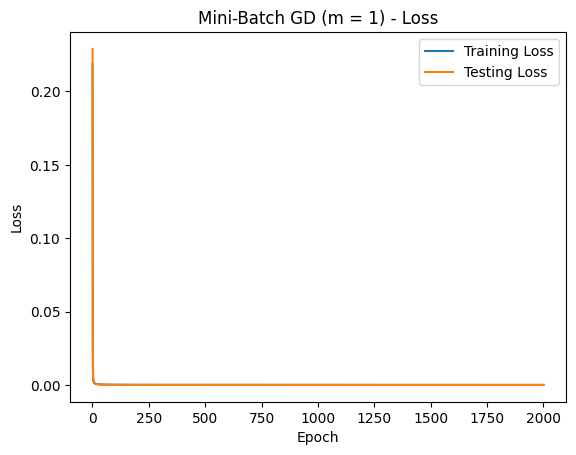

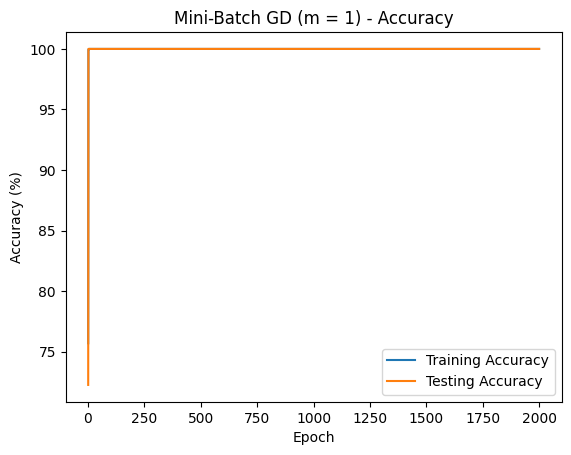


------------------------------------
Training with batch size m = 32
------------------------------------
Epoch 0: Train Loss=0.2499, Test Loss=0.2524
Epoch 500: Train Loss=0.1271, Test Loss=0.1221
Epoch 1000: Train Loss=0.1267, Test Loss=0.1221
Epoch 1500: Train Loss=0.1266, Test Loss=0.1220
Final Training Loss: 0.1265289650677756
Final Testing Loss: 0.12168477298503337
Final Training Accuracy: 75.6875 %
Final Testing Accuracy: 72.25 %


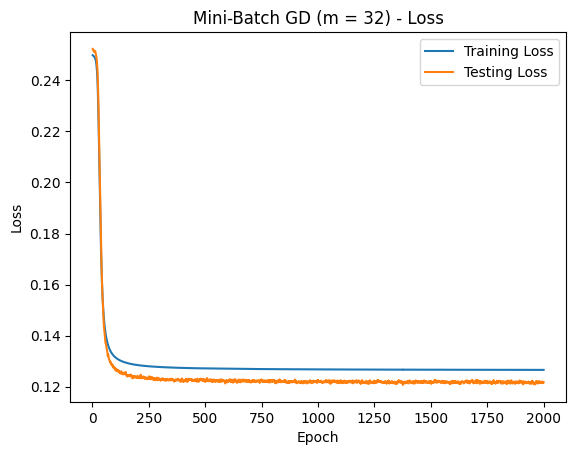

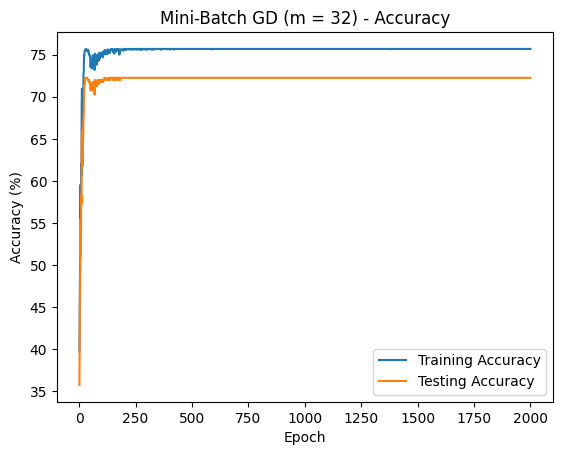


------------------------------------
Training with batch size m = 256
------------------------------------
Epoch 0: Train Loss=0.2500, Test Loss=0.2528
Epoch 500: Train Loss=0.1359, Test Loss=0.1320
Epoch 1000: Train Loss=0.1296, Test Loss=0.1249
Epoch 1500: Train Loss=0.1283, Test Loss=0.1234
Final Training Loss: 0.12775231735397707
Final Testing Loss: 0.12285587550482534
Final Training Accuracy: 75.6875 %
Final Testing Accuracy: 72.25 %


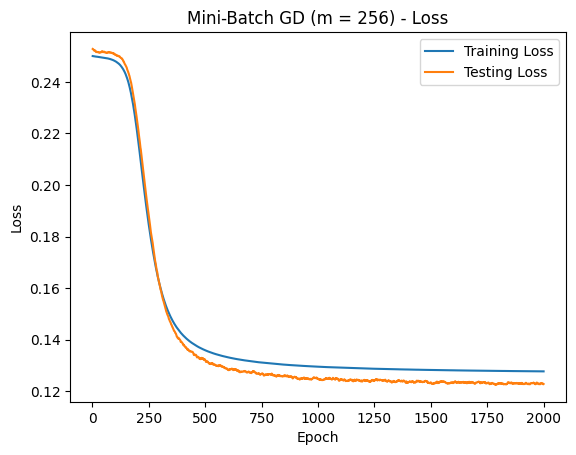

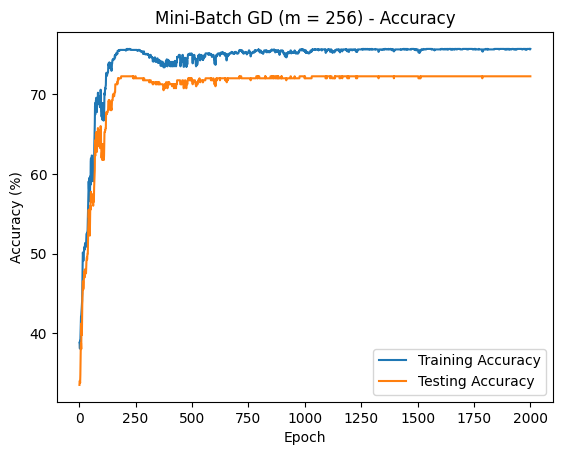

In [ ]:
# =========================
# Mini-Batch / Stochastic GD Experiment (XOR)
# =========================

# Fix dataset size
n = 2000

print("\n====================================")
print(f"Running Mini-Batch GD with dataset size n = {n}")
print("====================================")

X_train, y_train, X_test, y_test = generate_xor_dataset(
    samples_per_point=n // 4,
    noise_std=0.1
)

# Different batch sizes
m_list = [1, 32, 256]

for m in m_list:

    print("\n------------------------------------")
    print(f"Training with batch size m = {m}")
    print("------------------------------------")

    #  Reinitialize network correctly (NEW CLASS FORMAT)
    net = SimpleANN(
        input_size=2,
        hidden_size=2,
        output_size=1,
        hidden_act=tanh,
        hidden_act_deriv=tanh_derivative,
        output_act=sigmoid,
        output_act_deriv=sigmoid_derivative
    )

    #  Train with task specified
    train_losses, test_losses, train_accs, test_accs = train(
        net,
        X_train, y_train,
        X_test, y_test,
        epochs=2000,
        learning_rate=0.1,
        batch_size=m,
        task="xor"   # IMPORTANT
    )

    print("Final Training Loss:", train_losses[-1])
    print("Final Testing Loss:", test_losses[-1])
    print("Final Training Accuracy:", train_accs[-1], "%")
    print("Final Testing Accuracy:", test_accs[-1], "%")

    # Plot Loss
    epochs_arr = np.arange(1, len(train_losses) + 1)

    plt.figure()
    plt.plot(epochs_arr, train_losses, label="Training Loss")
    plt.plot(epochs_arr, test_losses, label="Testing Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Mini-Batch GD (m = {m}) - Loss")
    plt.legend()
    plt.show()

    # Plot Accuracy
    plt.figure()
    plt.plot(epochs_arr, train_accs, label="Training Accuracy")
    plt.plot(epochs_arr, test_accs, label="Testing Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.title(f"Mini-Batch GD (m = {m}) - Accuracy")
    plt.legend()
    plt.show()


Running Mini-Batch GD (Cosine) with dataset size n = 2000

------------------------------------
Training with batch size m = 1
------------------------------------
Epoch 0: Train Loss=0.2576, Test Loss=0.2478
Epoch 500: Train Loss=0.0001, Test Loss=0.0001
Epoch 1000: Train Loss=0.0001, Test Loss=0.0001
Epoch 1500: Train Loss=0.0002, Test Loss=0.0001
Epoch 2000: Train Loss=0.0001, Test Loss=0.0001
Epoch 2500: Train Loss=0.0001, Test Loss=0.0001
Final Training Loss: 0.00013019405722944127
Final Testing Loss: 0.00012960089808025955
Final Training Accuracy: 100.0 %
Final Testing Accuracy: 100.0 %


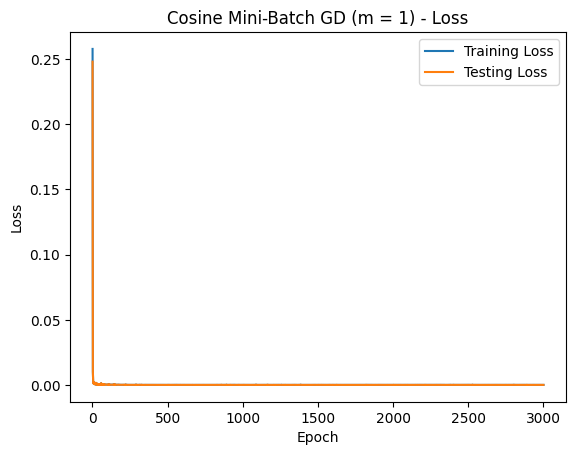

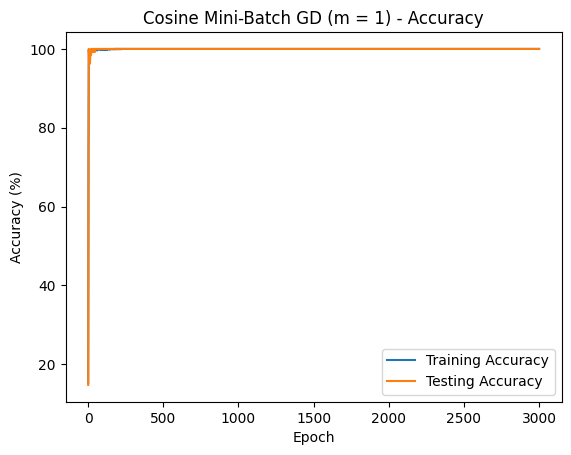


------------------------------------
Training with batch size m = 32
------------------------------------
Epoch 0: Train Loss=0.5184, Test Loss=0.5012
Epoch 500: Train Loss=0.0008, Test Loss=0.0008
Epoch 1000: Train Loss=0.0006, Test Loss=0.0006
Epoch 1500: Train Loss=0.0006, Test Loss=0.0006
Epoch 2000: Train Loss=0.0005, Test Loss=0.0005
Epoch 2500: Train Loss=0.0005, Test Loss=0.0005
Final Training Loss: 0.0004914348265868027
Final Testing Loss: 0.0004985761711940436
Final Training Accuracy: 99.5625 %
Final Testing Accuracy: 99.75 %


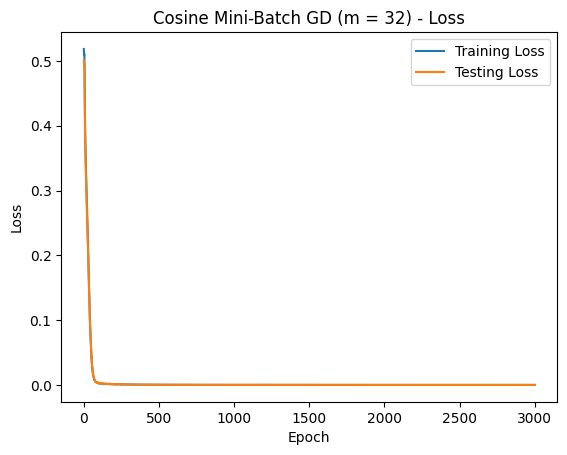

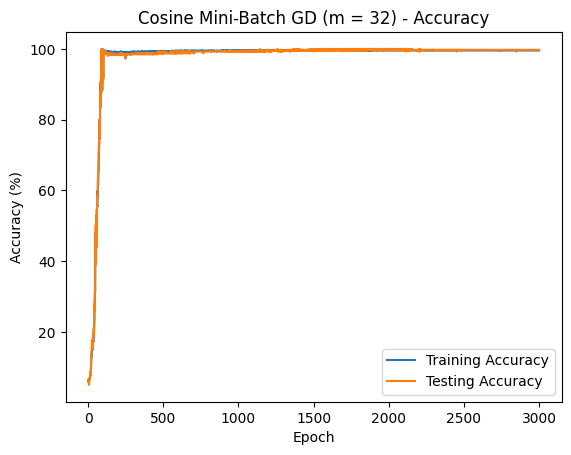


------------------------------------
Training with batch size m = 256
------------------------------------
Epoch 0: Train Loss=0.5282, Test Loss=0.5109
Epoch 500: Train Loss=0.0100, Test Loss=0.0095
Epoch 1000: Train Loss=0.0021, Test Loss=0.0022
Epoch 1500: Train Loss=0.0015, Test Loss=0.0016
Epoch 2000: Train Loss=0.0012, Test Loss=0.0013
Epoch 2500: Train Loss=0.0010, Test Loss=0.0011
Final Training Loss: 0.0008581573111634999
Final Testing Loss: 0.0009261968563971529
Final Training Accuracy: 99.1875 %
Final Testing Accuracy: 98.75 %


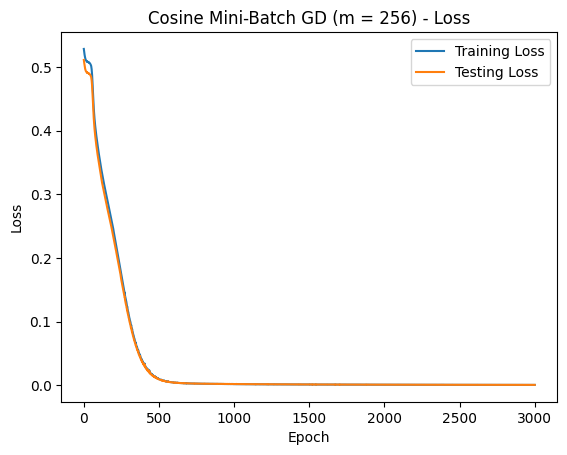

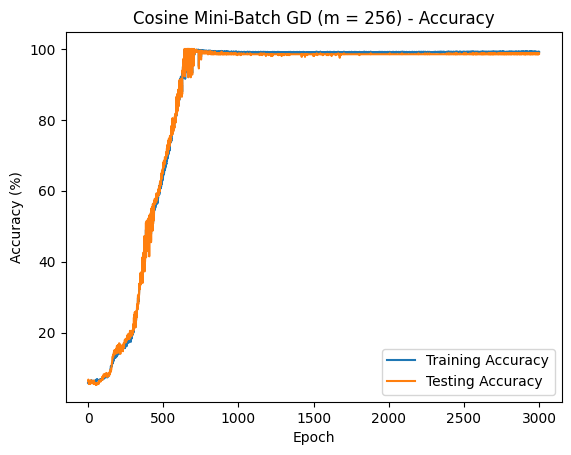

In [ ]:
# ============================================================
# Mini-Batch / Stochastic GD Experiment (Cosine)
# ============================================================

# Fix dataset size
n = 2000

print("\n====================================")
print(f"Running Mini-Batch GD (Cosine) with dataset size n = {n}")
print("====================================")

# Generate dataset
X_train, y_train, X_test, y_test = generate_cosine_dataset(
    n_samples=n,
    noise_std=0.1
)

# Different batch sizes
m_list = [1, 32, 256]

for m in m_list:

    print("\n------------------------------------")
    print(f"Training with batch size m = {m}")
    print("------------------------------------")

    # Reinitialize network (Hidden size = 2)
    net = SimpleANN(
        input_size=1,
        hidden_size=2,
        output_size=1,
        hidden_act=tanh,
        hidden_act_deriv=tanh_derivative,
        output_act=linear,
        output_act_deriv=linear_derivative
    )

    train_losses, test_losses, train_accs, test_accs = train(
        net,
        X_train, y_train,
        X_test, y_test,
        epochs=3000,
        learning_rate=0.01,
        batch_size=m,
        task="cosine"
    )

    print("Final Training Loss:", train_losses[-1])
    print("Final Testing Loss:", test_losses[-1])
    print("Final Training Accuracy:", train_accs[-1], "%")
    print("Final Testing Accuracy:", test_accs[-1], "%")

    # Plot Loss
    epochs_arr = np.arange(1, len(train_losses) + 1)

    plt.figure()
    plt.plot(epochs_arr, train_losses, label="Training Loss")
    plt.plot(epochs_arr, test_losses, label="Testing Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Cosine Mini-Batch GD (m = {m}) - Loss")
    plt.legend()
    plt.show()

    # Plot Accuracy
    plt.figure()
    plt.plot(epochs_arr, train_accs, label="Training Accuracy")
    plt.plot(epochs_arr, test_accs, label="Testing Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.title(f"Cosine Mini-Batch GD (m = {m}) - Accuracy")
    plt.legend()
    plt.show()